# Model Inference — All Study Visits (Medicated / Unmedicated)

Loops through every participant visit defined in the study CSV, loads the corresponding
day's motion data CSV, extracts a **5-minute window starting at the visit's 2.5-hour mark**,
and runs model inference.

The study CSV column `Visit Start Time (2.5 hours)` already encodes the start time
(i.e. 2.5 hours into the actual clinic visit).  We read 5 minutes of data from that
timestamp onward, matching the model's training window.

**Expected directory layout (one folder per participant × device):**
```
data/
  25001_2005/
    motion_data_2025-11-15.csv
    motion_data_2025-11-24.csv
    ...
  25002_2002/
    ...
```

In [ ]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.signal import find_peaks
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_DIR   = Path('./data/')

STUDY_CSV  = DATA_DIR / 'LemurDx-LemurDxStudyDatesWat_DATA_LABELS_2026-02-26_1003.xlsx - in.csv'
MODEL_PATH = DATA_DIR / 'model.pkl'
WINDOW_MIN = 5          # length of each inference window (minutes)
SCORE_THRESHOLD = 0.5  # for "time above threshold" stat

# Set to True  → score per window = P(ADHD) from model.pkl
# Set to False → score per window = mean acceleration magnitude (no model)
USE_MODEL = True
# ─────────────────────────────────────────────────────────────────────────────

visits = pd.read_csv(STUDY_CSV)
visits.columns = [c.strip() for c in visits.columns]
visits['start_dt'] = pd.to_datetime(visits['Visit Start Time (2.5 hours)'], format='%m/%d/%y %H:%M')
print(f'Loaded {len(visits)} visits')

Loaded 36 visits


In [2]:
# Compute Y_PEAK_NORM_MEAN / STD from your own data
# ⚠️  Only use these if retraining a new model — do NOT pass into model.pkl
# all_peak_counts = []
# window_ms_calc = WINDOW_MIN * 60 * 1000

# for _, row in visits.iterrows():
#     pid      = str(row['Participant ID']).strip()
#     watch    = str(row['LemurDx Watch ID']).strip()
#     start_dt = row['start_dt']
#     csv_path = DATA_DIR / f'{pid}_{watch}' / f'motion_data_{start_dt.strftime("%Y-%m-%d")}.csv'
#     if not csv_path.exists():
#         continue
#     try:
#         df = pd.read_csv(csv_path)
#         df['time'] = pd.to_datetime(df['time'])
#         df = df[df['time'] >= start_dt].sort_values('time').reset_index(drop=True)
#         df['ms'] = (df['time'] - df['time'].iloc[0]).dt.total_seconds() * 1000
#         i = 0
#         while True:
#             chunk = df[(df['ms'] >= i * window_ms_calc) & (df['ms'] < (i+1) * window_ms_calc)]
#             if len(chunk) < 10:
#                 break
#             peak_count = len(find_peaks(chunk['acceleration_y'].values)[0])
#             all_peak_counts.append(peak_count)
#             i += 1
#     except Exception:
#         pass

# all_peak_counts = np.array(all_peak_counts)
# new_mean = all_peak_counts.mean()
# new_std  = all_peak_counts.std()
# print(f'Your data:     mean={new_mean:.2f}, std={new_std:.2f}  (n={len(all_peak_counts)} windows)')
# print(f'Original model: mean=658.05, std=139.76')
# print()
# print('If retraining, set:')
# print(f'  Y_PEAK_NORM_MEAN = {new_mean}')
# print(f'  Y_PEAK_NORM_STD  = {new_std}')


In [3]:
with open(MODEL_PATH, 'rb') as f:
    model = pickle.load(f)

FEATURE_NAMES = list(model.feature_names_in_)
print('Model feature names:', FEATURE_NAMES)

Y_PEAK_NORM_MEAN = 3452.1593959731545
Y_PEAK_NORM_STD  = 770.7924296199118

#Y_PEAK_NORM_MEAN = 658.0510204081633
#Y_PEAK_NORM_STD  = 139.75513064175715

def model_score(df_window):
    """Return P(ADHD) for one 5-min window using model.pkl."""
    df = df_window.copy()
    df['ts'] = (df['time'] - df['time'].iloc[0]).dt.total_seconds() * 1000
    df['w5']  = (df['ts'] / 5000).astype(int)
    df['w60'] = (df['ts'] / 60000).astype(int)

    f1 = df.groupby('w5')['acceleration_x'].apply(
        lambda x: np.argmin(np.abs(np.fft.fft(x)[1:(1 + len(x)//2)]))
    ).median()
    f2 = df.groupby('w60')['acceleration_z'].apply(stats.iqr).mean()
    f3 = (df.groupby('w60')['acceleration_y'].apply(
        lambda x: len(find_peaks(x)[0])
    ).mean() - Y_PEAK_NORM_MEAN) / Y_PEAK_NORM_STD

    # order matches model.feature_names_in_: [f1, f3, f2]
    X = pd.DataFrame([[f1, f3, f2]], columns=FEATURE_NAMES)
    return model.predict_proba(X)[0][0]   # P(ADHD)

def motion_score(df_window):
    """Return mean acceleration magnitude for one window."""
    mag = np.sqrt(df_window['acceleration_x']**2 +
                  df_window['acceleration_y']**2 +
                  df_window['acceleration_z']**2)
    return mag.mean()

score_fn   = model_score  if USE_MODEL else motion_score
score_label = 'P(ADHD)'  if USE_MODEL else 'Accel magnitude'
print(f'\nUsing: {score_label}')

Model feature names: ['5.0_x-fft-argmin (median)', '60.0_normalized_y-peak_count (mean)', '60.0_z-fft-iqr (mean)']

Using: Accel magnitude


/home/shreya/miniconda3/envs/lemurdx-data/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/shreya/miniconda3/envs/lemurdx-data/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
results = []
window_ms       = WINDOW_MIN * 60 * 1000
MAX_DURATION_MS = 2.5 * 60 * 60 * 1000  # 2.5-hour cap

for _, row in visits.iterrows():
    pid      = str(row['Participant ID']).strip()
    watch    = str(row['LemurDx Watch ID']).strip()
    event    = row['Event Name'].strip()
    med      = row['Medication Status'].strip()
    start_dt = row['start_dt']
    date_str = start_dt.strftime('%Y-%m-%d')
    csv_path = DATA_DIR / f'{pid}_{watch}' / f'motion_data_{date_str}.csv'

    if not csv_path.exists():
        print(f'[SKIP] {pid} {event} ({date_str}) — file not found')
        continue

    try:
        df = pd.read_csv(csv_path)
        df['time'] = pd.to_datetime(df['time'])
        df = df[df['time'] >= start_dt].sort_values('time').reset_index(drop=True)

        if len(df) == 0:
            print(f'[SKIP] {pid} {event} ({date_str}) — no data at or after {start_dt}')
            continue

        df['ms'] = (df['time'] - df['time'].iloc[0]).dt.total_seconds() * 1000

        # Score each 5-minute window, capped at 2.5 hours
        window_scores = []
        i = 0
        while i * window_ms < MAX_DURATION_MS:
            chunk = df[(df['ms'] >= i * window_ms) & (df['ms'] < (i + 1) * window_ms)]
            i += 1
            if len(chunk) < 10:
                continue
            window_scores.append(score_fn(chunk))
            

        if not window_scores:
            print(f'[SKIP] {pid} {event} ({date_str}) — no complete windows')
            continue

        s = np.array(window_scores)
        print(f'[OK] {pid} {event} ({date_str}) ({med}) — {len(s)} windows — mean={s.mean():.3f}')
        results.append({
            'participant_id':    pid,
            'event':             event,
            'date':              date_str,
            'medication_status': med,
            'n_windows':         len(s),
            'mean':              s.mean(),
            'variance':          s.var(),
            'q75':               np.percentile(s, 75),
            'q25':               np.percentile(s, 25),
            'time_above':        (s > SCORE_THRESHOLD).mean(),
            'window_scores':     s.tolist(),
        })

    except Exception as e:
        print(f'[ERROR] {pid} {event} ({date_str}): {e}')

results_df = pd.DataFrame(results)
print(f'\n{len(results_df)} visits processed')


[OK] 25001 Visit 1 (2025-11-15) (Unmedicated) — 16 windows — mean=0.160
[OK] 25001 Visit 2 (2025-11-24) (Medicated) — 1 windows — mean=0.056
[OK] 25002 Visit 1 (2025-10-13) (Unmedicated) — 22 windows — mean=0.197
[OK] 25002 Visit 2 (2025-10-27) (Medicated) — 22 windows — mean=0.134
[OK] 25003 Visit 1 (2025-10-18) (Unmedicated) — 11 windows — mean=0.223
[SKIP] 25003 Visit 2 (2025-11-15) — file not found
[OK] 25004 Visit 1 (2025-10-21) (Medicated) — 5 windows — mean=0.075
[OK] 25004 Visit 2 (2025-11-08) (Unmedicated) — 21 windows — mean=0.184
[SKIP] 25005 Visit 1 (2025-10-23) — no data at or after 2025-10-23 17:00:00
[OK] 25005 Visit 2 (2025-11-06) (Medicated) — 18 windows — mean=0.113
[OK] 25006 Visit 1 (2025-10-30) (Unmedicated) — 23 windows — mean=0.150
[OK] 25006 Visit 2 (2025-11-12) (Medicated) — 19 windows — mean=0.094
[OK] 25007 Visit 1 (2025-11-06) (Medicated) — 28 windows — mean=0.163
[SKIP] 25007 Visit 2 (2025-11-21) — file not found
[OK] 25010 Visit 1 (2025-12-11) (Unmedicated

In [5]:
STAT_COLS = ['mean', 'variance', 'q75', 'q25', 'time_above']
STAT_LABELS = {
    'mean':       f'Mean {score_label}',
    'variance':   f'Variance of {score_label}',
    'q75':        'Top quartile (Q75)',
    'q25':        'Bottom quartile (Q25)',
    'time_above': f'Fraction of windows > {SCORE_THRESHOLD}',
}

print(results_df[['participant_id', 'event', 'medication_status', 'n_windows'] + STAT_COLS].to_string(index=False))
print('\n--- Mean by medication status ---')
print(results_df.groupby('medication_status')[STAT_COLS].mean().round(4))

participant_id   event medication_status  n_windows     mean  variance      q75      q25  time_above
         25001 Visit 1       Unmedicated         16 0.160167  0.028506 0.136507 0.063130    0.062500
         25001 Visit 2         Medicated          1 0.055563  0.000000 0.055563 0.055563    0.000000
         25002 Visit 1       Unmedicated         22 0.197008  0.036039 0.213959 0.088840    0.090909
         25002 Visit 2         Medicated         22 0.133718  0.030078 0.088810 0.055212    0.090909
         25003 Visit 1       Unmedicated         11 0.222724  0.023059 0.311825 0.102567    0.090909
         25004 Visit 1         Medicated          5 0.074942  0.000994 0.101176 0.059369    0.000000
         25004 Visit 2       Unmedicated         21 0.183891  0.032747 0.185842 0.055292    0.142857
         25005 Visit 2         Medicated         18 0.113466  0.020850 0.083952 0.043691    0.000000
         25006 Visit 1       Unmedicated         23 0.150085  0.039287 0.167968 0.040088   

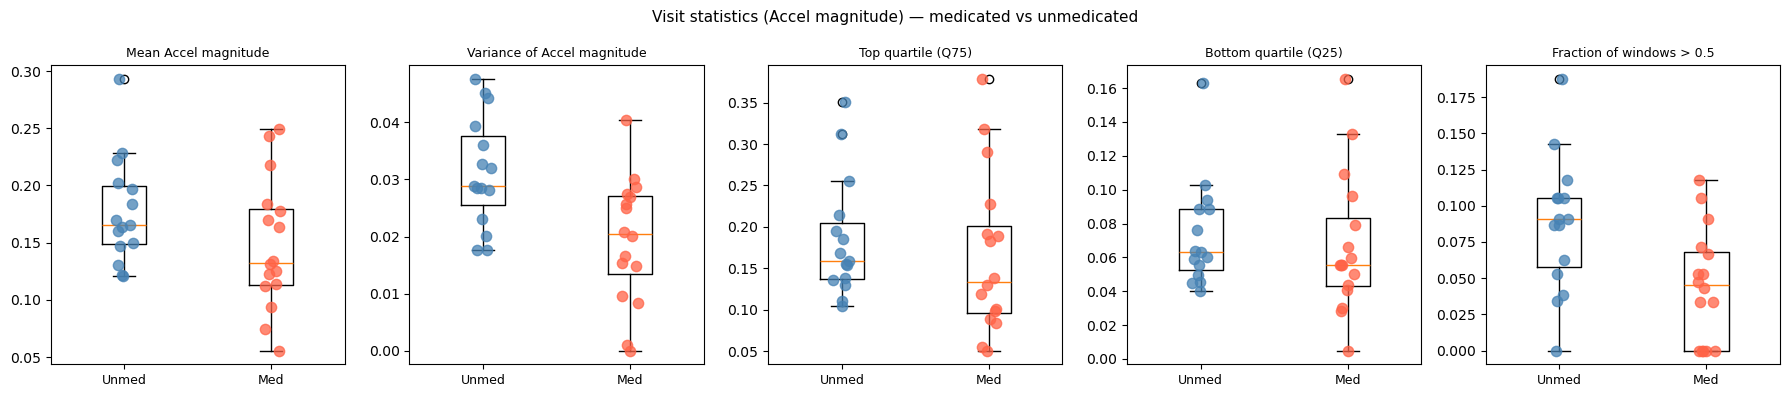

12 participants with both visits



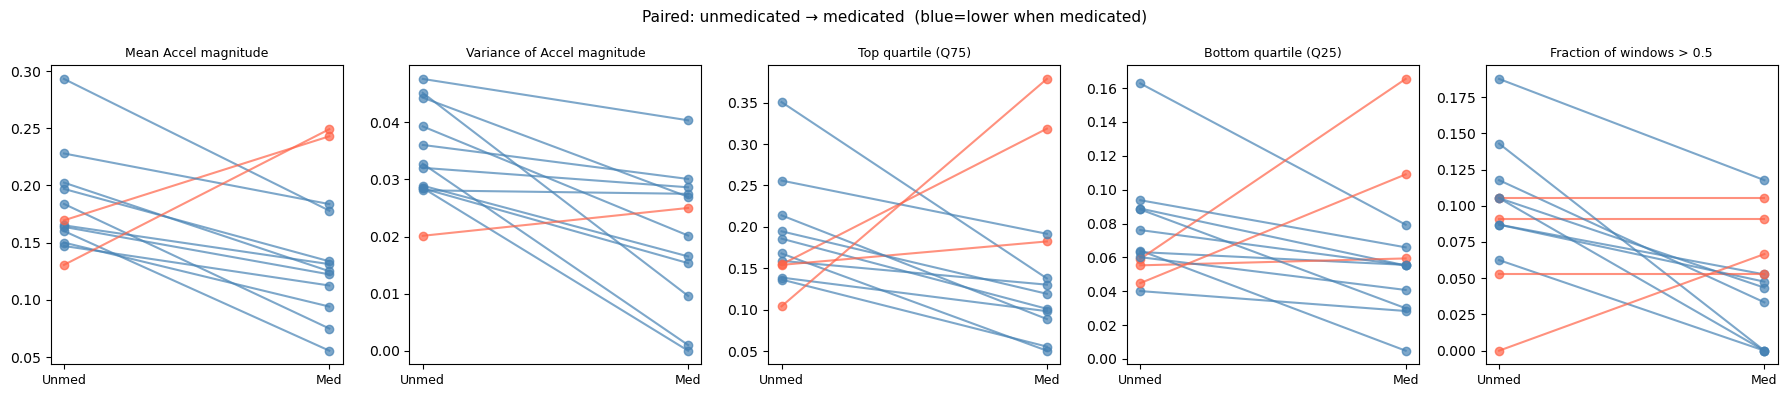

In [6]:
# Plots: box + strip and paired lines for each stat
colors = {'Medicated': 'tomato', 'Unmedicated': 'steelblue'}

fig, axes = plt.subplots(1, len(STAT_COLS), figsize=(18, 4))

for ax, col in zip(axes, STAT_COLS):
    for med_status, grp in results_df.groupby('medication_status'):
        x = 1 if med_status == 'Medicated' else 0
        jitter = np.random.uniform(-0.06, 0.06, len(grp))
        ax.scatter(x + jitter, grp[col], color=colors[med_status], alpha=0.75, s=55, zorder=3)
    ax.boxplot([results_df[results_df['medication_status'] == 'Unmedicated'][col],
                results_df[results_df['medication_status'] == 'Medicated'][col]],
               positions=[0, 1], widths=0.3, zorder=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Unmed', 'Med'], fontsize=9)
    ax.set_title(STAT_LABELS[col], fontsize=9)

plt.suptitle(f'Visit statistics ({score_label}) — medicated vs unmedicated', fontsize=11)
plt.tight_layout()
plt.show()

# Paired line plots (one per participant with both visits)
paired = []
for pid, grp in results_df.groupby('participant_id'):
    med   = grp[grp['medication_status'] == 'Medicated']
    unmed = grp[grp['medication_status'] == 'Unmedicated']
    if len(med) and len(unmed):
        entry = {'participant_id': pid}
        for col in STAT_COLS:
            entry[f'{col}_med']   = med[col].values[0]
            entry[f'{col}_unmed'] = unmed[col].values[0]
        paired.append(entry)

paired_df = pd.DataFrame(paired)
print(f'{len(paired_df)} participants with both visits\n')

if len(paired_df) >= 2:
    fig, axes = plt.subplots(1, len(STAT_COLS), figsize=(18, 4))
    for ax, col in zip(axes, STAT_COLS):
        for _, row in paired_df.iterrows():
            u, m = row[f'{col}_unmed'], row[f'{col}_med']
            c = 'steelblue' if m < u else 'tomato'
            ax.plot([0, 1], [u, m], marker='o', color=c, alpha=0.7, linewidth=1.5)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Unmed', 'Med'], fontsize=9)
        ax.set_title(STAT_LABELS[col], fontsize=9)
    plt.suptitle(f'Paired: unmedicated → medicated  (blue=lower when medicated)', fontsize=11)
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import skew as scipy_skew, kurtosis as scipy_kurtosis
from scipy.signal import find_peaks as scipy_find_peaks

results_df['label'] = (results_df['medication_status'] == 'Medicated').astype(int)

# ── Extract features from window_scores ───────────────────────────────────────
def extract_features(row):
    scores = np.array(row['window_scores'])
    n = len(scores)
    autocorr = float(pd.Series(scores).autocorr(lag=1)) if n > 2 else 0.0
    n_peaks  = len(scipy_find_peaks(scores)[0]) if n > 2 else 0
    return {
        'mean':          row['mean'],
        'variance':      row['variance'],
        'time_above':    row['time_above'],
        'max_score':     scores.max(),
        'min_score':     scores.min(),
        'iqr':           float(np.percentile(scores, 75) - np.percentile(scores, 25)),
        'skewness':      float(scipy_skew(scores)) if n > 2 else 0.0,
        'kurtosis':      float(scipy_kurtosis(scores)) if n > 2 else 0.0,
        'autocorr_lag1': autocorr,
        'n_peaks':       n_peaks,
    }

feat_df = pd.DataFrame([extract_features(r) for _, r in results_df.iterrows()])
feat_df['participant_id'] = results_df['participant_id'].values
feat_df['label']          = results_df['label'].values

ALL_FEAT_COLS = ['mean', 'variance', 'time_above', 'max_score', 'min_score',
                 'iqr', 'skewness', 'kurtosis', 'autocorr_lag1', 'n_peaks']

participants = feat_df['participant_id'].unique()

# ── Classifiers to evaluate ───────────────────────────────────────────────────
classifiers = {
    'LR':          LogisticRegression(C=1, max_iter=2000),
    'LR L1':       LogisticRegression(C=0.1, penalty='l1', solver='liblinear', max_iter=2000),
    'SVM-lin':     SVC(kernel='linear', C=0.1, probability=True),
    'SVM-rbf':     SVC(kernel='rbf', C=1, probability=True),
    'RF (d2)':     RandomForestClassifier(n_estimators=200, max_depth=2, random_state=42),
    'RF (d3)':     RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42),
    'GradBoost':   GradientBoostingClassifier(n_estimators=50, max_depth=2, random_state=42),
    'GNB':         GaussianNB(),
    'LDA':         LinearDiscriminantAnalysis(),
}

# ── LOO-CV: each classifier × SelectKBest for k=1,2,3,5 ─────────────────────
print(f'{"Model":<22} {"k":>3}  {"Acc":>6}  {"AUC":>6}  {"Correct":>8}  top features')
print('-' * 90)

summary = []
for k in [1, 2, 3, 5]:
    for clf_name, clf in classifiers.items():
        y_true_all, y_pred_all, y_proba_all = [], [], []
        details_rows = []
        selection_counts = {f: 0 for f in ALL_FEAT_COLS}

        for test_pid in participants:
            train = feat_df[feat_df['participant_id'] != test_pid]
            test  = feat_df[feat_df['participant_id'] == test_pid]
            if len(np.unique(train['label'].values)) < 2:
                continue

            X_train = train[ALL_FEAT_COLS].values
            X_test  = test[ALL_FEAT_COLS].values
            y_train = train['label'].values
            y_test  = test['label'].values

            scaler  = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

            selector = SelectKBest(f_classif, k=k)
            X_train  = selector.fit_transform(X_train, y_train)
            X_test   = selector.transform(X_test)
            for feat, sel in zip(ALL_FEAT_COLS, selector.get_support()):
                if sel:
                    selection_counts[feat] += 1

            clf.fit(X_train, y_train)
            preds  = clf.predict(X_test)
            probas = clf.predict_proba(X_test)[:, 1]

            y_true_all.extend(y_test)
            y_pred_all.extend(preds)
            y_proba_all.extend(probas)
            med_status_vals = results_df[results_df['participant_id'] == test_pid]['event'].values
            for i in range(len(y_test)):
                details_rows.append({
                    'participant_id': test_pid,
                    'event':       med_status_vals[i] if i < len(med_status_vals) else '?',
                    'true':        'Medicated' if y_test[i] else 'Unmedicated',
                    'predicted':   'Medicated' if preds[i] else 'Unmedicated',
                    'p_medicated': round(probas[i], 3),
                    'correct':     preds[i] == y_test[i],
                })

        acc = accuracy_score(y_true_all, y_pred_all)
        auc = roc_auc_score(y_true_all, y_proba_all) if len(np.unique(y_true_all)) > 1 else float('nan')
        n_correct = sum(np.array(y_true_all) == np.array(y_pred_all))
        top = sorted(selection_counts.items(), key=lambda x: -x[1])
        top_str = ', '.join(f[0] for f, _ in zip(top, range(k)))
        name = f'{clf_name}(k={k})'
        print(f'{name:<22} {k:>3}  {acc:>6.3f}  {auc:>6.3f}  {n_correct:>3}/{len(y_true_all)}  {top_str}')
        summary.append({'name': name, 'k': k, 'accuracy': acc, 'auc': auc,
                        'correct': n_correct, 'total': len(y_true_all),
                        '_details': details_rows, '_true': y_true_all, '_pred': y_pred_all})

# ── Best model details ────────────────────────────────────────────────────────
best = max(summary, key=lambda x: x['auc'])
print(f'\n── Best by AUC: {best["name"]} ──')
best_details = pd.DataFrame(best['_details'])
print(best_details.to_string(index=False))
print(f'\nLOO Accuracy: {best["accuracy"]:.3f}  ({best["correct"]}/{best["total"]} correct)')
print(f'LOO AUC:      {best["auc"]:.3f}')
print(pd.DataFrame(confusion_matrix(best['_true'], best['_pred']),
                   index=['true Unmed', 'true Med'],
                   columns=['pred Unmed', 'pred Med']))


In [8]:
# ── Per-participant summary ───────────────────────────────────────────────────
best_df = pd.DataFrame(best_details)

per_p = best_df.groupby('participant_id').apply(lambda g: pd.Series({
    'n_visits':      len(g),
    'n_correct':     g['correct'].sum(),
    'all_correct':   g['correct'].all(),
    'med_p':         g[g['true'] == 'Medicated']['p_medicated'].values.tolist(),
    'unmed_p':       g[g['true'] == 'Unmedicated']['p_medicated'].values.tolist(),
    'med_correct':   g[g['true'] == 'Medicated']['correct'].all()   if len(g[g['true'] == 'Medicated'])   else None,
    'unmed_correct': g[g['true'] == 'Unmedicated']['correct'].all() if len(g[g['true'] == 'Unmedicated']) else None,
}), include_groups=False).reset_index()

print('Per-participant results (best classifier):\n')
print(f"{'PID':<8} {'Med p_med':>10} {'Unmed p_med':>12} {'Med✓':>6} {'Unmed✓':>8} {'Both✓':>7}")
print('-' * 55)
for _, r in per_p.iterrows():
    med_p   = ', '.join(f'{x:.3f}' for x in r['med_p'])   or '—'
    unmed_p = ', '.join(f'{x:.3f}' for x in r['unmed_p']) or '—'
    med_ok   = ('✓' if r['med_correct']   else '✗') if r['med_correct']   is not None else '—'
    unmed_ok = ('✓' if r['unmed_correct'] else '✗') if r['unmed_correct'] is not None else '—'
    both_ok  = '✓' if r['all_correct'] else '✗'
    print(f"{r['participant_id']:<8} {med_p:>10} {unmed_p:>12} {med_ok:>6} {unmed_ok:>8} {both_ok:>7}")

n_both   = per_p['all_correct'].sum()
n_paired = per_p[per_p['n_visits'] == 2].shape[0]
print(f'\n{n_both}/{len(per_p)} participants fully correct  |  {n_paired} with both visits')


Per-participant results (best classifier):

PID       Med p_med  Unmed p_med   Med✓   Unmed✓   Both✓
-------------------------------------------------------
25001         0.919        0.462      ✓        ✓       ✓
25002         0.397        0.275      ✗        ✓       ✗
25003             —        0.596      —        ✗       ✗
25004         0.905        0.369      ✓        ✓       ✓
25005         0.602            —      ✓        —       ✓
25006         0.621        0.241      ✓        ✓       ✓
25007         0.492            —      ✗        —       ✗
25010         0.703        0.447      ✓        ✓       ✓
25011    0.809, 0.709            —      ✓        —       ✓
25012             —        0.728      —        ✗       ✗
25013         0.467        0.153      ✗        ✓       ✗
25014         0.435        0.361      ✗        ✓       ✗
25015         0.806        0.162      ✓        ✓       ✓
25016         0.725        0.458      ✓        ✓       ✓
25018         0.146        0.069      ✗    